In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import matplotlib.patches as mpatches
import matplotlib as mpl

# ---- Adobe-friendly fonts (must be set BEFORE plotting) ----
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42


df = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-starved/speed_over_time.csv')

df["condition"] = np.where(df["track"] == 0, "starved", "fed")

order = ['fed', 'starved']
palette = {'starved': "#F3D00E", 'fed': '#0B5D2A'}




In [26]:

df['time_bin'] = ((df['time'] - 1) // 600) * 600 + 1
df['time_bin_label'] = df['time_bin'].astype(int).astype(str) + '-' + (df['time_bin'] + 599).astype(int).astype(str)

speed_bins = df.groupby(['condition', 'file', 'time_bin', 'time_bin_label']).agg(
    average_speed=('speed', 'mean')
).reset_index()



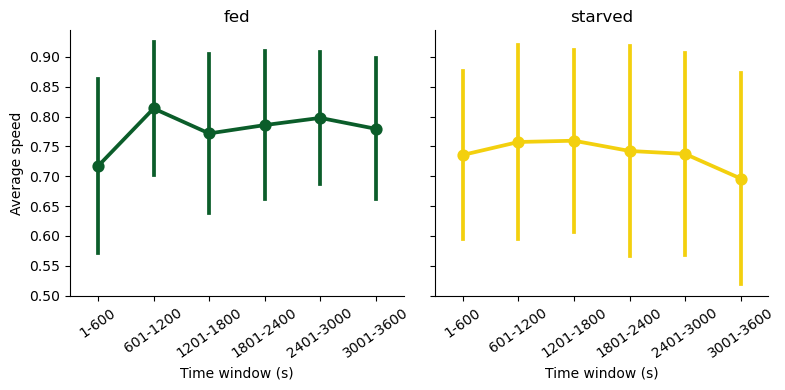

In [27]:
# each condition separately
fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

for ax, condition in zip(axes, order):
    sub = speed_bins[speed_bins['condition'] == condition]
    sns.pointplot(
        data=sub,
        x='time_bin_label',
        y='average_speed',
        color=palette[condition],
        errorbar='sd',
        ax=ax,
    )
    ax.set_title(condition)
    ax.set_xlabel('Time window (s)')
    ax.set_ylabel('Average speed')
    ax.tick_params(axis='x', rotation=35)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()


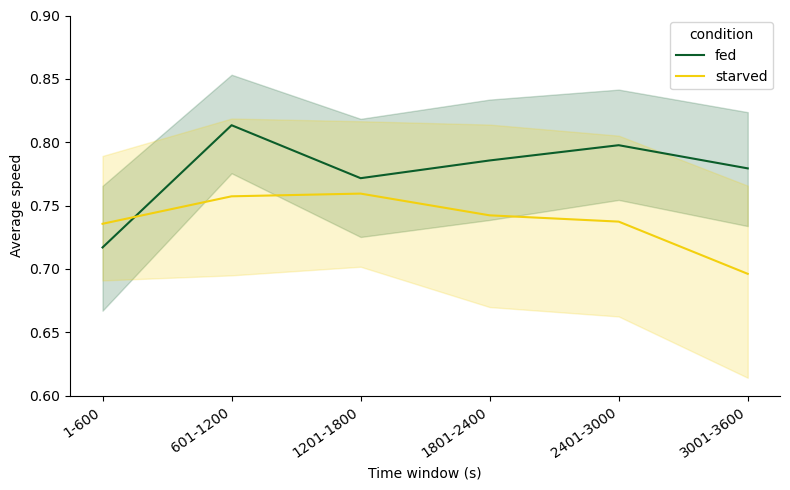

In [28]:
# group-housed conditions together, 95% confidence interval
fig, ax = plt.subplots(figsize=(8, 5))

sns.lineplot(
    data=speed_bins,
    x='time_bin',
    y='average_speed',
    hue='condition',
    hue_order=order,
    palette=palette,
    errorbar=('ci', 95),
    ax=ax,
)

tick_positions = sorted(speed_bins['time_bin'].unique())
tick_labels = [
    speed_bins.loc[speed_bins['time_bin'] == time_bin, 'time_bin_label'].iloc[0]
    for time_bin in tick_positions
]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=35, ha='right')
ax.set_xlabel('Time window (s)')
ax.set_ylabel('Average speed')
sns.despine(ax=ax)
ax.set_ylim(0.6, 0.9)

plt.tight_layout()
plt.show()


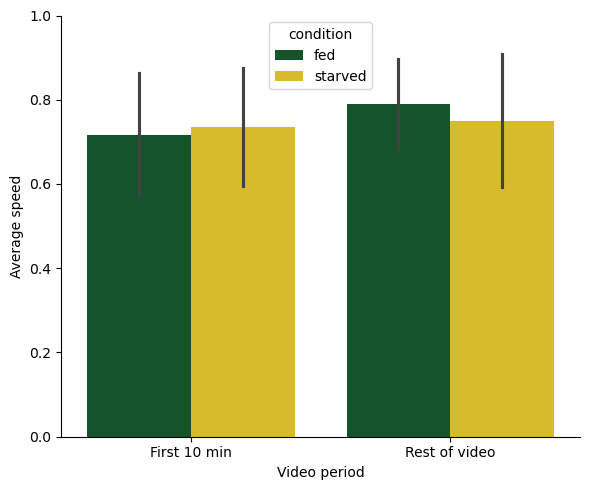

,video_period,condition_a,condition_b,n_a,n_b,u_statistic,p_value
0,First 10 min,fed,starved,28,28,386.0,0.928186
1,Rest of video,fed,starved,28,25,410.0,0.289083


In [29]:
# first 10 minutes vs rest of video
from itertools import combinations
from scipy.stats import mannwhitneyu

df['video_period'] = np.where(df['time'] <= 600, 'First 10 min', 'Rest of video')
period_order = ['First 10 min', 'Rest of video']

speed_periods = df.groupby(['condition', 'file', 'video_period']).agg(
    average_speed=('speed', 'mean')
).reset_index()

fig, ax = plt.subplots(figsize=(6, 5))

sns.barplot(
    data=speed_periods,
    x='video_period',
    y='average_speed',
    hue='condition',
    order=period_order,
    hue_order=order,
    palette=palette,
    errorbar='sd',
    ax=ax,
)

ax.set_xlabel('Video period')
ax.set_ylabel('Average speed')
ax.set_ylim(0, 1)
sns.despine(ax=ax)

# plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/gh/speed.pdf', format='pdf')
plt.tight_layout()
plt.show()

# Mann-Whitney U tests between conditions within each video period
mann_whitney_results = []

for period in period_order:
    period_data = speed_periods[speed_periods['video_period'] == period]

    for condition_a, condition_b in combinations(order, 2):
        speeds_a = period_data.loc[
            period_data['condition'] == condition_a,
            'average_speed'
        ].dropna()
        speeds_b = period_data.loc[
            period_data['condition'] == condition_b,
            'average_speed'
        ].dropna()

        if speeds_a.empty or speeds_b.empty:
            u_statistic = np.nan
            p_value = np.nan
        else:
            test = mannwhitneyu(speeds_a, speeds_b, alternative='two-sided')
            u_statistic = test.statistic
            p_value = test.pvalue

        mann_whitney_results.append({
            'video_period': period,
            'condition_a': condition_a,
            'condition_b': condition_b,
            'n_a': len(speeds_a),
            'n_b': len(speeds_b),
            'u_statistic': u_statistic,
            'p_value': p_value,
        })

mann_whitney_results = pd.DataFrame(mann_whitney_results)
mann_whitney_results


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_29217/1293050666.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


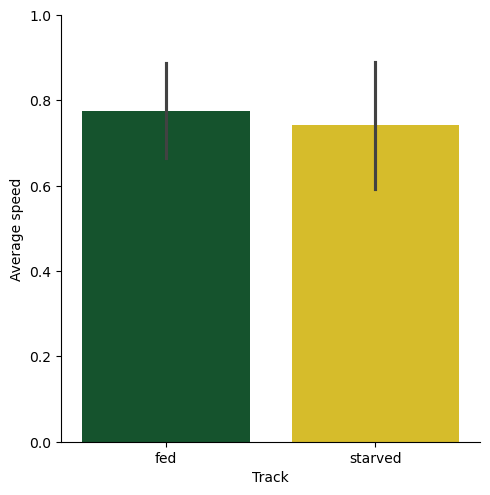

Track fed vs track starved
Mann-Whitney U = 445
p = 0.3896


In [34]:
# speed by track, with SD error bars
from scipy.stats import mannwhitneyu

track_speed_summary = (
    df
    .groupby(['file', 'condition'], as_index=False)['speed']
    .mean()
)

track_order = sorted(track_speed_summary['condition'].dropna().unique())

fig, ax = plt.subplots(figsize=(5, 5))

sns.barplot(
    data=track_speed_summary,
    x='condition',
    y='speed',
    order=track_order,
    palette=palette,
    errorbar='sd',
    ax=ax,
)

ax.set_xlabel('Track')
ax.set_ylabel('Average speed')
sns.despine(ax=ax)
plt.tight_layout()
plt.ylim(0, 1)
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/gh/fed-starved/avg_speed.pdf', format='pdf')
plt.show()


track_0 = track_speed_summary.loc[track_speed_summary['condition'] == track_order[0], 'speed'].dropna()
track_1 = track_speed_summary.loc[track_speed_summary['condition'] == track_order[1], 'speed'].dropna()

test = mannwhitneyu(track_0, track_1, alternative='two-sided')

print(f'Track {track_order[0]} vs track {track_order[1]}')
print(f'Mann-Whitney U = {test.statistic:.4g}')
print(f'p = {test.pvalue:.4g}')
